# IGRF-RFE-SHAP-IDS-UNSW-NB15: Explainable AI & SHAP Interpretability

This notebook implements **SHAP (SHapley Additive exPlanations)** on our best-performing XGBoost classifier. Instead of treating the booster as a black box, SHAP allows us to interpret how features pull predictions toward specific security classes (like Fuzzers or Exploits).

### Visualizations Generated
1. **Summary Bar Plot**: Global feature importance across classes.
2. **Summary Beeswarm Plot**: Details on how feature magnitudes shift outputs.
3. **Dependency Plots**: Interaction plots between two related variables.
4. **Force / Waterfall Plots**: Explaining individual packet prediction reasons.

In [1]:
# Install SHAP library if needed
!pip install shap

In [2]:
import os
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Enable JS visualization in notebook
shap.initjs()

/home/aryanp/Desktop/IIIT Intership/Model on UNSW‑NB15/.venv_linux/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
print("=== Loading and Preprocessing ===")
train_df = pd.read_csv('data/UNSW_NB15_training-set.csv')
test_df = pd.read_csv('data/UNSW_NB15_testing-set.csv')

if 'attack_cat' in train_df.columns:
    train_df.rename(columns={'attack_cat': 'AR'}, inplace=True)
    test_df.rename(columns={'attack_cat': 'AR'}, inplace=True)

keep_classes = ['Normal', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Reconnaissance']
combined = pd.concat([train_df, test_df], ignore_index=True)
combined = combined[combined['AR'].isin(keep_classes)]

selected_features = [
    'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
    'dbytes', 'rate', 'sttl', 'dttl', 'dload', 'dloss', 'sinpkt',
    'dinpkt', 'djit', 'tcprtt', 'synack', 'ackdat', 'smean',
    'dmean', 'ct_state_ttl', 'ct_dst_src_ltm'
]
combined = combined[selected_features + ['AR']]
combined.dropna(inplace=True)

X = combined.drop('AR', axis=1)
y = combined['AR']

for feat in ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'dload', 'dloss', 'sinpkt', 'dinpkt', 'djit', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean']:
    X[feat] = np.log1p(X[feat])

X = pd.get_dummies(X, columns=['proto', 'service', 'state'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_train.columns)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

=== Loading and Preprocessing ===


In [6]:
# Load pre-trained attempt model (from models/ folder)
model_path = 'models/xgb_attempt5.joblib'
if os.path.exists(model_path):
    print(f"Loading {model_path}...")
    xgb_model = joblib.load(model_path)
else:
    from xgboost import XGBClassifier
    print("Training quick model since xgb_attempt5 was not found...")
    xgb_model = XGBClassifier(n_estimators=100, max_depth=8, learning_rate=0.1, random_state=42, n_jobs=-1, eval_metric='mlogloss')
    xgb_model.fit(X_train_scaled, y_train_enc)

Loading models/xgb_attempt5.joblib...


## Calculate SHAP values (Using TreeExplainer)

In [7]:
explainer = shap.TreeExplainer(xgb_model)
# Sample a subset to speed up explainability calculation
X_sample = X_test_scaled.sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample)
print("SHAP values calculated successfully. Shape:", np.shape(shap_values))

SHAP values calculated successfully. Shape: (500, 177, 6)


## Summary Plot (Global Importance across classes)

<Figure size 1000x800 with 0 Axes>

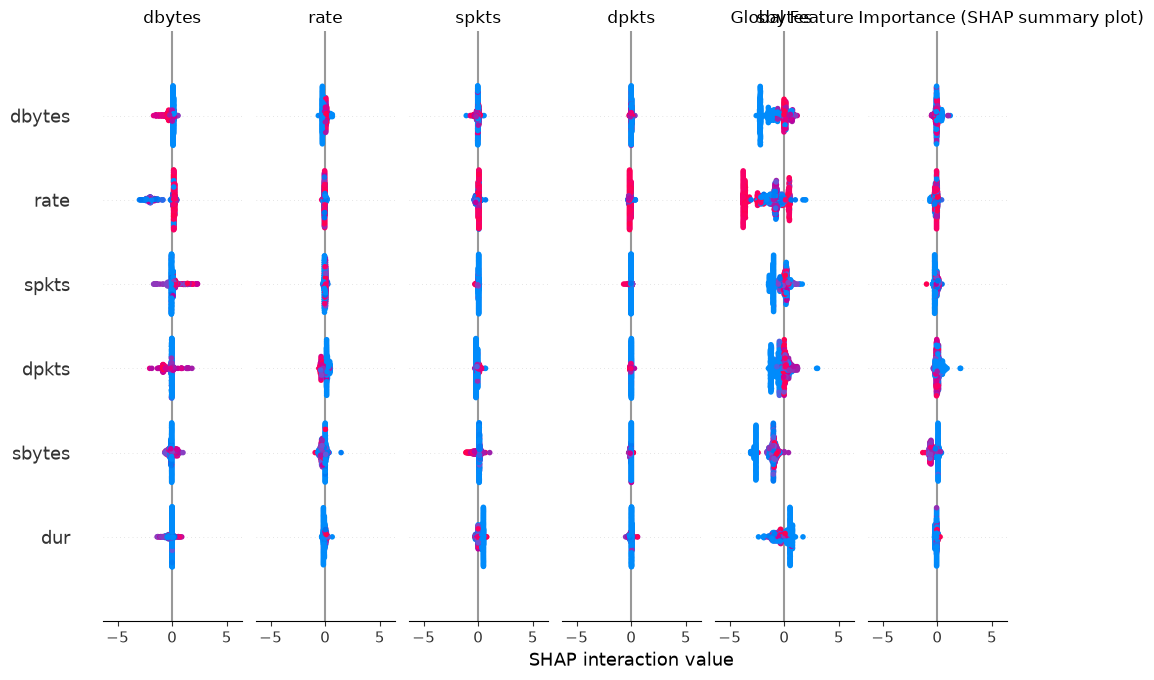

In [8]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, class_names=le.classes_, show=False)
plt.title("Global Feature Importance (SHAP summary plot)")
plt.show()

## Beeswarm Plot for Exploit Class (Class index 2)

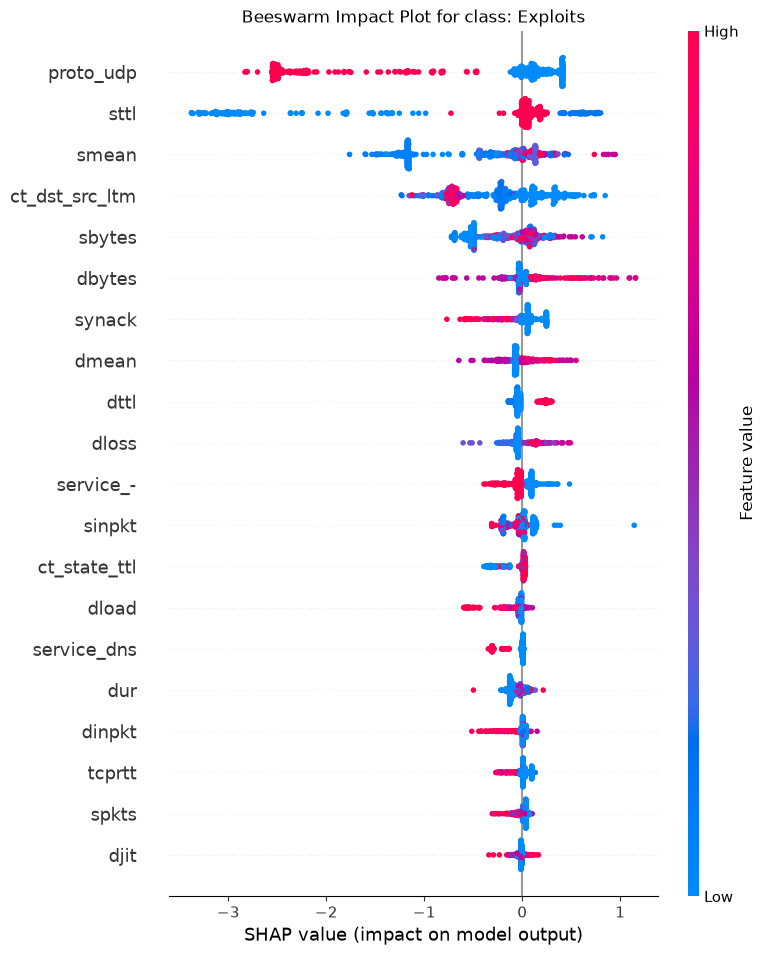

In [10]:
exploit_class_idx = list(le.classes_).index('Exploits')
plt.figure(figsize=(10, 8))
if isinstance(shap_values, list):
    class_shap = shap_values[exploit_class_idx]
else:
    class_shap = shap_values[:, :, exploit_class_idx] if len(shap_values.shape) == 3 and shap_values.shape[2] == len(le.classes_) else shap_values[exploit_class_idx]
shap.summary_plot(class_shap, X_sample, show=False)
plt.title(f"Beeswarm Impact Plot for class: Exploits")
plt.show()

## Explaining a Single flow (Force Plot)

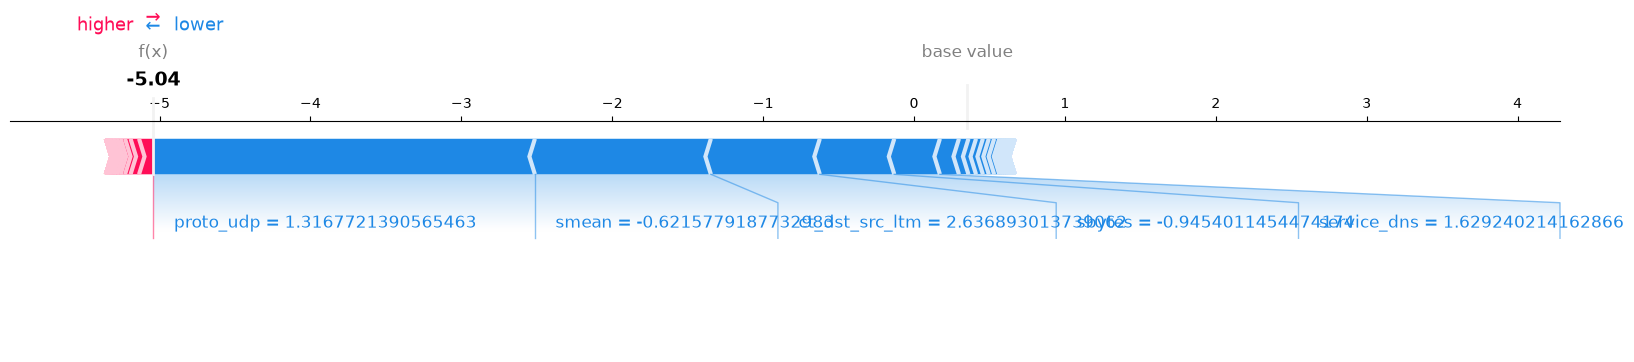

In [11]:
# Select first index from sample
single_record_idx = 0
exploit_class_idx = list(le.classes_).index('Exploits')
if isinstance(shap_values, list):
    class_shap = shap_values[exploit_class_idx]
else:
    class_shap = shap_values[:, :, exploit_class_idx] if len(shap_values.shape) == 3 and shap_values.shape[2] == len(le.classes_) else shap_values[exploit_class_idx]

shap.force_plot(
    explainer.expected_value[exploit_class_idx], 
    class_shap[single_record_idx], 
    X_sample.iloc[single_record_idx], 
    matplotlib=True
)